# QUESTIONS BEING EXPLORED
1. Which sites are the biggest by acreage?
2. What is the shape distribution across the data?
3. What are the most common planting seasons?
4. Are there any cross-checking patterns between variables?

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('forest-restoration-tracking-1.csv')
df.head()

,SiteName,GISPropNum,InitPlntSn,Acreage,DtaColMthd,Shape
0,Inwood Hill Park,M042,1995,0.092,Drawing,0xD70800000104050000008032436761A72E4100F873F1...
1,Inwood Hill Park,M042,1995,0.137,Drawing,0xD70800000104050000000044E2D171A62E410024CCEE...
2,Inwood Hill Park,M042,1995,0.178,Drawing,0xD70800000104050000008002BAA60FA52E4100C67A47...
3,Inwood Hill Park,M042,2000 Fall,0.041,Drawing,0xD708000001040500000080109244BEAF2E4100422879...
4,NaN,M042,1997,0.105,Drawing,0xD7080000010406000000006A8B625DA22E4100EEFD2A...


In [3]:
df.value_counts().sum()

np.int64(1513)

In [4]:
df.shape

(1541, 6)

In [5]:
df.columns

Index(['SiteName', 'GISPropNum', 'InitPlntSn', 'Acreage', 'DtaColMthd',
       'Shape'],
      dtype='object')

In [6]:
df.isnull().sum()

SiteName      22
GISPropNum     2
InitPlntSn     1
Acreage        0
DtaColMthd     3
Shape          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(17)

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df_sorted = df.sort_values(by="Acreage", ascending=False)
df_sorted[["SiteName", "Acreage"]].head(10)

,SiteName,Acreage
1280,Flushing Meadows Park - Willow Lake,23.264
1325,Rockaway Community Park,8.243
303,New York Botanical Gardens,7.173
567,Marine Park,6.333
37,Bronx River,5.553
1222,Alley Pond Park,5.384
53,Bronx Park,5.141
286,Riverdale Park,5.041
1351,Penn & Fountain Landfill,4.916
1429,Freshkills Park,4.560


# 1. Which sites are biggest (Acreage)

In [10]:
df["Acreage"].info()

<class 'pandas.core.series.Series'>
Index: 1524 entries, 0 to 1540
Series name: Acreage
Non-Null Count  Dtype  
--------------  -----  
1524 non-null   float64
dtypes: float64(1)
memory usage: 23.8 KB


In [11]:
df["Acreage"].describe()

count    1524.000000
mean        0.446028
std         0.919522
min         0.000000
25%         0.068000
50%         0.186500
75%         0.471000
max        23.264000
Name: Acreage, dtype: float64

[]

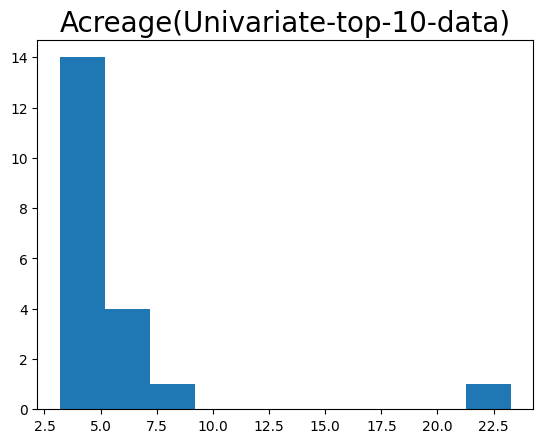

In [12]:
plt.hist(df_sorted['Acreage'].head(20))
plt.title('Acreage(Univariate-top-10-data)',size = 20)
plt.plot()

 #### Flushing Meadows Park - Willow Lake is the biggest site with 23.264 acres, followed by Rockaway Community Park with 8.243 acres.

# 2. Shape distribution (Polygon vs Point)

In [13]:
df["Shape"].value_counts().sum()

np.int64(1524)

In [14]:
df["Shape"].isnull().sum()

np.int64(0)

In [15]:
df["Shape"].info()

<class 'pandas.core.series.Series'>
Index: 1524 entries, 0 to 1540
Series name: Shape
Non-Null Count  Dtype 
--------------  ----- 
1524 non-null   object
dtypes: object(1)
memory usage: 23.8+ KB


In [16]:
df["Shape"].describe()

count                                                  1524
unique                                                 1431
top       0xD708000001040600000000709481C00E3041004A15C4...
freq                                                      3
Name: Shape, dtype: object

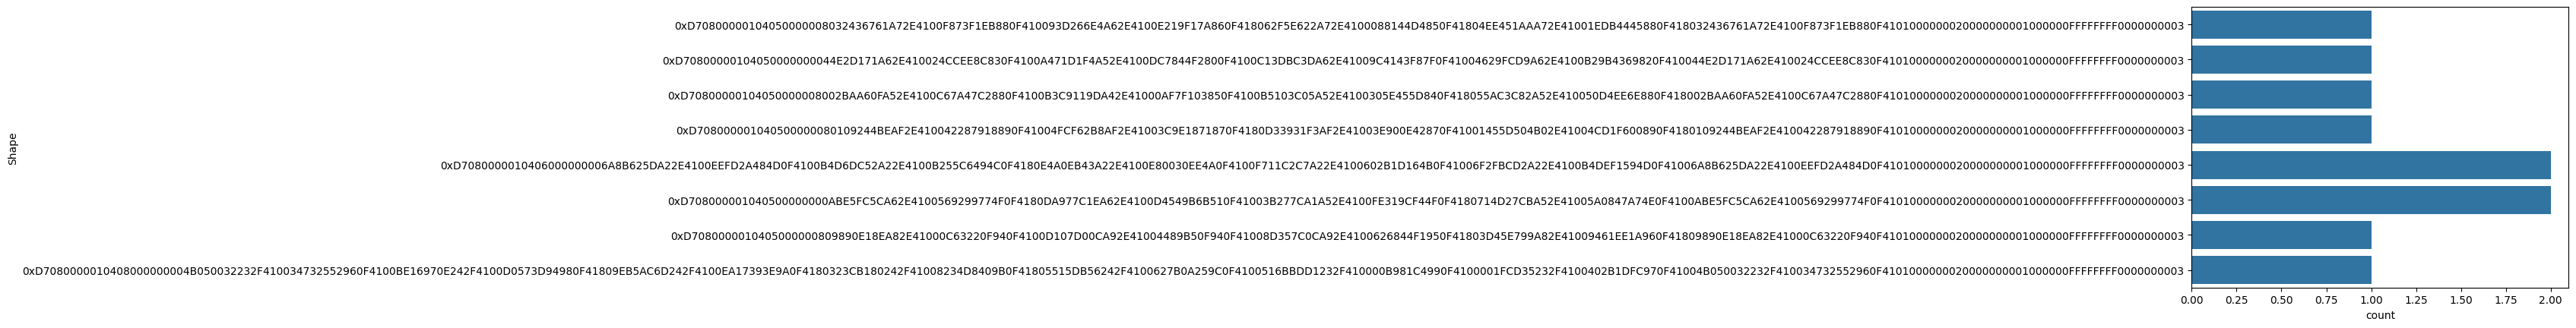

In [17]:
sns.countplot(df['Shape'].head(10))
plt.show()
# df['Shape'].head(5).value_counts().plot(kind = 'pie')

#### There are 1,524 unique shape records with 1,431 distinct geometric values, showing highly diverse spatial representations with minimal overlap.

# 3. Most common planting seasons

In [18]:
print(df['InitPlntSn'].value_counts().sum())

1523


In [19]:
print(df['InitPlntSn'].dtype)

object


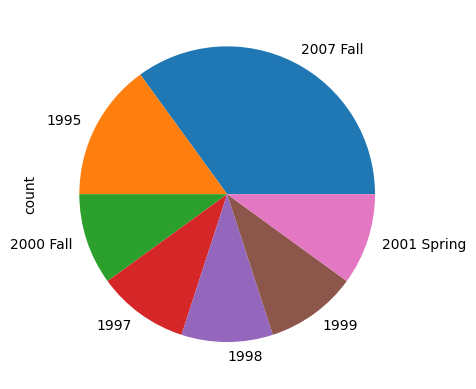

In [20]:
df['InitPlntSn'].head(20).value_counts().plot(kind = 'pie')
plt.show()

#### The InitPlntSn column contains 1,523 non-null values as categorical data representing different planting years and seasons distributed across the dataset.

# 4. Cross-check patterns

Compare Shape vs Acreage

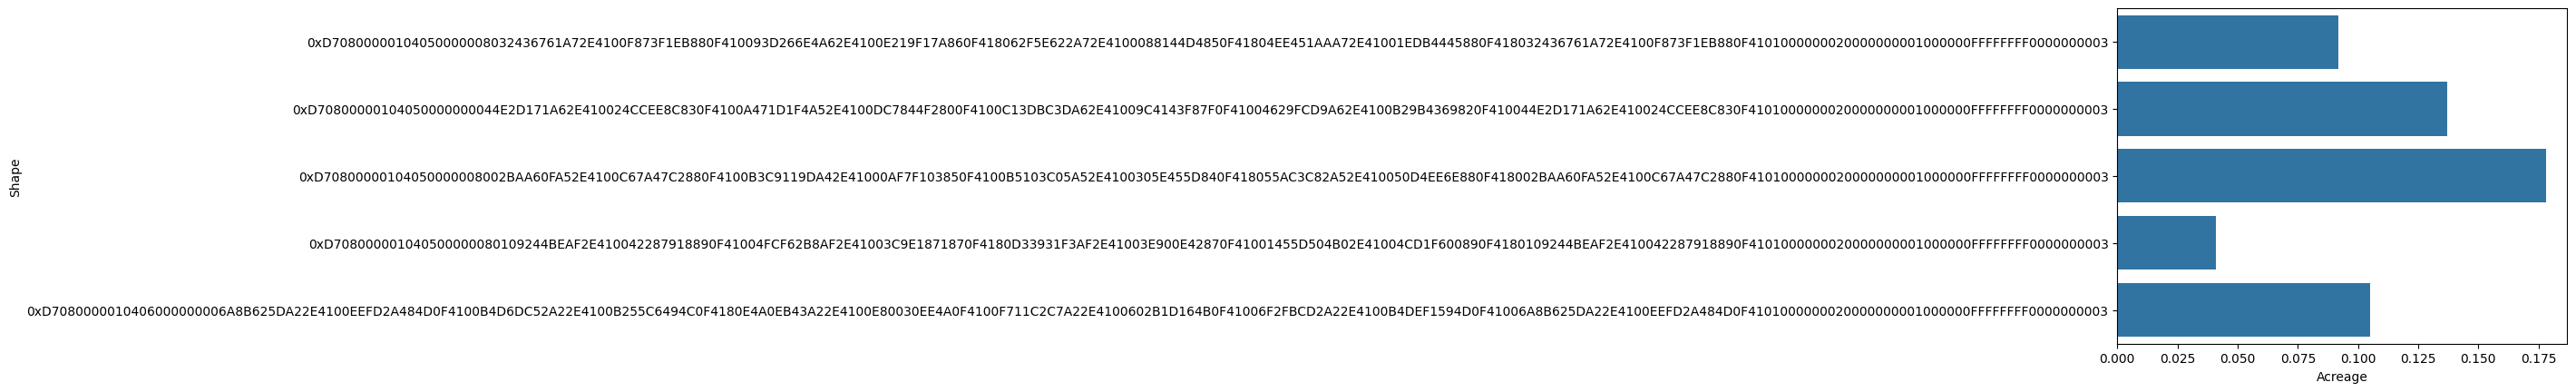

In [25]:
sns.barplot(x = 'Acreage',y= 'Shape',data = df.head(5))
plt.show()

Compare InitPlntSn vs Acreage

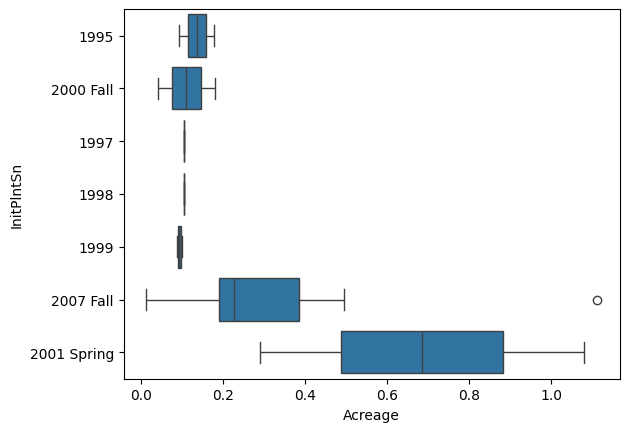

In [30]:
sns.boxplot(x = 'Acreage',y= 'InitPlntSn',data = df.head(20))
plt.show()

#### The notebook explores relationships between Shape-Acreage and InitPlntSn-Acreage through bar plots, though specific correlation patterns are not quantitatively analyzed in the code.

# 5. Summary

This notebook presents an exploratory data analysis (EDA) of a forest restoration tracking dataset containing 1,541 records across six attributes. After removing 17 duplicate entries, 1,524 unique records were analyzed.

The dataset includes site information, GIS property numbers, planting seasons, acreage, data collection methods, and spatial geometry data. Data cleaning identified a few missing values in SiteName, GISPropNum, InitPlntSn, and DtaColMthd, while Acreage and Shape columns were complete.

Acreage analysis shows most restoration sites are small, with values ranging from 0 to 23.264 acres and a few larger outliers. Visualizations using Matplotlib and Seaborn were applied to understand distributions and patterns in the dataset.